# Customer Churn Prediction

## Business Problem

A telecommunications company wants to identify customers who are likely to churn.
The objective of this project is to build an end-to-end machine-learning solution
that predicts customer churn and helps the retention team take proactive action.

**Target Variable:** Churn (`Yes` / `No`)

---

## Step 1: Data Understanding and Initial Data Audit

In this section, we will load the raw dataset and inspect its structure,
data types, missing values, duplicate records, feature types, and churn distribution.

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib fastapi uvicorn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
DATA_PATH = "../data/TelcoCustomerChurn.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset loaded successfully.
Dataset shape: 7043 rows and 21 columns


### Initial Observation

The dataset contains **7,043 customer records** and **21 columns**.
Each row represents one telecom customer. The dataset includes customer demographic,
service, contract, billing, and charge information, with `Churn` as the target variable.

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.sample(5, random_state=42)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Dataset Structure Observations

- The dataset contains 7,043 records and 21 columns.
- All columns have 7,043 non-null values, indicating that no standard missing values
  are present at the time of loading.
- `SeniorCitizen`, `tenure`, and `MonthlyCharges` are already represented as numeric values.
- Most remaining columns are categorical customer, service, contract, and billing features.
- `customerID` is a unique identifier and will be excluded from model training after
  checking its uniqueness.
- `TotalCharges` is currently stored as text even though it represents a numerical amount.
  It requires further inspection for hidden blank values and conversion to numeric format.

In [7]:
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df) * 100).round(2)
})

missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Missing Percentage


In [8]:
missing_summary

,Missing Values,Missing Percentage
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


In [9]:
blank_counts = df.apply(
    lambda column: column.astype(str).str.strip().eq("").sum()
)

blank_counts[blank_counts > 0]

TotalCharges    11
dtype: int64

In [10]:
total_charges_blank_count = (
    df["TotalCharges"]
    .astype(str)
    .str.strip()
    .eq("")
    .sum()
)

print(f"Blank values in TotalCharges: {total_charges_blank_count}")

Blank values in TotalCharges: 11


In [11]:
total_charges_blank_rows = df[
    df["TotalCharges"].astype(str).str.strip().eq("")
]

total_charges_blank_rows[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [12]:
total_charges_blank_rows = df[
    df["TotalCharges"].astype(str).str.strip().eq("")
]

total_charges_blank_rows[
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


### Decision: Handling `TotalCharges`

The blank values in `TotalCharges` were investigated before cleaning. All 11 affected
customers have `tenure = 0`, indicating that they are new customers with no completed
billing history.

Therefore, blank `TotalCharges` values will be converted to missing values and replaced
with `0.0`. This is business-consistent because `TotalCharges` represents cumulative
charges, and customers with zero tenure have not yet accumulated charges.

In [13]:
# Convert blank strings to missing values, then convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True),
    errors="coerce"
)

# Customers with tenure = 0 have no accumulated charges
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

print(f"TotalCharges data type: {df['TotalCharges'].dtype}")
print(f"Missing values in TotalCharges: {df['TotalCharges'].isna().sum()}")
print(f"Customers with tenure = 0: {(df['tenure'] == 0).sum()}")
print(f"TotalCharges equal to 0: {(df['TotalCharges'] == 0).sum()}")

TotalCharges data type: float64
Missing values in TotalCharges: 0
Customers with tenure = 0: 11
TotalCharges equal to 0: 11


### Validation After Cleaning `TotalCharges`

After conversion and cleaning:

- `TotalCharges` was successfully converted from text to the numerical `float64` data type.
- No missing values remain in `TotalCharges`.
- The dataset contains 11 customers with `tenure = 0`.
- All 11 of these customers now have `TotalCharges = 0.0`.

This confirms that the cleaning approach preserved the business meaning of cumulative charges
for newly acquired customers.

### Duplicate Analysis

Duplicate records can bias exploratory analysis and model evaluation. Therefore, we check both:

1. Exact duplicate rows across all columns.
2. Duplicate customer identifiers, because each row should represent one unique customer.

In [14]:
exact_duplicate_rows = df.duplicated().sum()
duplicate_customer_ids = df["customerID"].duplicated().sum()

print(f"Exact duplicate rows: {exact_duplicate_rows}")
print(f"Duplicate customer IDs: {duplicate_customer_ids}")

Exact duplicate rows: 0
Duplicate customer IDs: 0


In [15]:
print(f"Unique customer IDs: {df['customerID'].nunique()}")
print(f"Total records: {len(df)}")

Unique customer IDs: 7043
Total records: 7043


### Duplicate Analysis Result

No duplicate records were found:

- Exact duplicate rows: 0
- Duplicate customer IDs: 0
- Unique customer IDs: 7,043, equal to the total number of records

Therefore, each row represents a distinct customer, and no rows were removed during
duplicate analysis.

In [16]:
numerical_columns = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


In [17]:
print("SeniorCitizen unique values:", sorted(df["SeniorCitizen"].unique()))
print(
    "Tenure range:",
    f"{df['tenure'].min()} to {df['tenure'].max()} months"
)
print(
    "MonthlyCharges range:",
    f"{df['MonthlyCharges'].min():.2f} to {df['MonthlyCharges'].max():.2f}"
)
print(
    "TotalCharges range:",
    f"{df['TotalCharges'].min():.2f} to {df['TotalCharges'].max():.2f}"
)

SeniorCitizen unique values: [np.int64(0), np.int64(1)]
Tenure range: 0 to 72 months
MonthlyCharges range: 18.25 to 118.75
TotalCharges range: 0.00 to 8684.80


### Numerical Feature Validation

The numerical variables show valid and business-plausible ranges:

- `SeniorCitizen` contains only 0 and 1, confirming that it is a binary indicator.
- `tenure` ranges from 0 to 72 months, representing both new and long-term customers.
- `MonthlyCharges` ranges from 18.25 to 118.75.
- `TotalCharges` ranges from 0.00 to 8,684.80. The zero values are valid because they
  correspond to the 11 customers with zero tenure.
- No impossible negative values or invalid numerical ranges were identified.

The distribution of `TotalCharges` will be examined further during exploratory data analysis,
as cumulative charges are expected to vary according to customer tenure and subscribed services.

In [18]:
categorical_columns = df.select_dtypes(include=["object", "string"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [19]:
for column in categorical_columns:
    print(f"\n{column} ({df[column].nunique()} unique values):")
    print(sorted(df[column].unique()))


customerID (7043 unique values):
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ', '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS', '0017-DINOC', '0017-IUDMW', '0018-NYROU', '0019-EFAEP', '0019-GFNTW', '0020-INWCK', '0020-JDNXP', '0021-IKXGC', '0022-TCJCI', '0023-HGHWL', '0023-UYUPN', '0023-XUOPT', '0027-KWYKW', '0030-FNXPP', '0031-PVLZI', '0032-PGELS', '0036-IHMOT', '0040-HALCW', '0042-JVWOJ', '0042-RLHYP', '0048-LUMLS', '0048-PIHNL', '0052-DCKON', '0052-YNYOT', '0056-EPFBG', '0057-QBUQH', '0058-EVZWM', '0060-FUALY', '0064-SUDOG', '0064-YIJGF', '0067-DKWBL', '0068-FIGTF', '0071-NDAFP', '0074-HDKDG', '0076-LVEPS', '0078-XZMHT', '0080-EMYVY', '0080-OROZO', '0082-LDZUE', '0082-OQIQY', '0083-PIVIK', '0089-IIQKO', '0093-EXYQL', '0093-XWZFY', '0094-OIFMO', '0096-BXERS', '0096-FCPUF', '0098-BOWSO', '0100-DUVFC', '0103-CSITQ', '0104-PPXDV', '0106-GHRQR', '0106-UGRDO', '0107-WESLM', '0107-YHINA', '0111-KLBQG', '0112-QAWRZ', '0112-QWPNC', '0114-IGABW',

In [20]:
categorical_columns_without_id = [
    column for column in categorical_columns
    if column != "customerID"
]

for column in categorical_columns_without_id:
    print(f"\n{column} ({df[column].nunique()} unique values):")
    print(sorted(df[column].unique()))


gender (2 unique values):
['Female', 'Male']

Partner (2 unique values):
['No', 'Yes']

Dependents (2 unique values):
['No', 'Yes']

PhoneService (2 unique values):
['No', 'Yes']

MultipleLines (3 unique values):
['No', 'No phone service', 'Yes']

InternetService (3 unique values):
['DSL', 'Fiber optic', 'No']

OnlineSecurity (3 unique values):
['No', 'No internet service', 'Yes']

OnlineBackup (3 unique values):
['No', 'No internet service', 'Yes']

DeviceProtection (3 unique values):
['No', 'No internet service', 'Yes']

TechSupport (3 unique values):
['No', 'No internet service', 'Yes']

StreamingTV (3 unique values):
['No', 'No internet service', 'Yes']

StreamingMovies (3 unique values):
['No', 'No internet service', 'Yes']

Contract (3 unique values):
['Month-to-month', 'One year', 'Two year']

PaperlessBilling (2 unique values):
['No', 'Yes']

PaymentMethod (4 unique values):
['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']

Churn (2 

### Categorical Feature Validation

All categorical variables contain valid and consistent values matching the data dictionary.
No spelling inconsistencies, unexpected categories, or hidden blank categories were identified.

Important handling decisions:

- `No phone service` in `MultipleLines` is a meaningful service-status category, not a missing value.
- `No internet service` in internet-dependent service columns is also a meaningful category,
  not a missing value.
- Categorical variables will later be encoded using one-hot encoding within a machine-learning
  pipeline so that the same transformation can be applied consistently to unseen customer data.

In [21]:
churn_counts = df["Churn"].value_counts()

churn_percentages = (
    df["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn_summary = pd.DataFrame({
    "Customer Count": churn_counts,
    "Percentage": churn_percentages
})

churn_summary

,Customer Count,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


In [22]:
print(f"Total customers: {len(df)}")
print(f"Churned customers: {(df['Churn'] == 'Yes').sum()}")
print(f"Retained customers: {(df['Churn'] == 'No').sum()}")

Total customers: 7043
Churned customers: 1869
Retained customers: 5174


### Target Variable Analysis: Customer Churn

The target variable, `Churn`, contains two classes:

| Churn Status | Customer Count | Percentage |
|---|---:|---:|
| No | 5,174 | 73.46% |
| Yes | 1,869 | 26.54% |

The dataset has a moderate class imbalance because non-churners represent 73.46% of
customers, while churners represent 26.54%.

Therefore:

- The train/test split will be stratified to preserve the churn proportion in both datasets.
- Accuracy alone will not be sufficient for model evaluation.
- Precision, recall, F1 score, and the confusion matrix will be included when evaluating
  the final model.
- Since the business objective is to proactively identify potential churners, recall for
  the `Churn = Yes` class will be especially important.

## Step 1 Summary: Data Understanding and Preparation Decisions

- The raw dataset contains 7,043 customer records and 21 columns.
- Each row represents one unique telecom customer.
- No standard missing values were detected.
- A hidden blank-value check identified 11 blank entries in `TotalCharges`.
- All 11 blank `TotalCharges` entries belonged to customers with `tenure = 0`; therefore,
  they were converted to numerical values and replaced with `0.0`.
- After cleaning, `TotalCharges` was stored as a numerical `float64` variable with no
  remaining missing values.
- No exact duplicate rows and no duplicate customer IDs were found.
- Numerical variables had valid and business-plausible ranges.
- Categorical variables contained valid, consistent categories, including meaningful
  service-status values such as `No internet service` and `No phone service`.
- `customerID` will be excluded from modelling because it is only a unique identifier.
- The target variable is moderately imbalanced: 26.54% of customers churned and 73.46%
  did not churn.
- A stratified 70:30 train/test split with `random_state=42` will be used later to
  preserve the churn ratio and ensure reproducible model evaluation.

# Step 2: Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand customer behaviour,
identify patterns associated with churn, and generate business insights that can
support customer-retention strategies.

The analysis includes churn distribution, customer/service characteristics,
churn against important customer attributes, and numerical feature relationships.

## 2.1 Churn Distribution

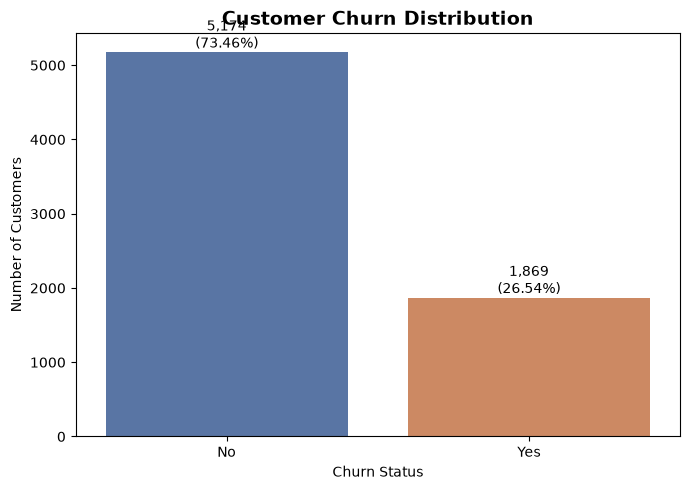

In [23]:
# Create a count plot for the target variable
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Churn",
    hue="Churn",
    palette={"No": "#4C72B0", "Yes": "#DD8452"},
    legend=False
)

plt.title("Customer Churn Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

# Add count and percentage labels above each bar
total_customers = len(df)

for bar in ax.patches:
    count = int(bar.get_height())
    percentage = count / total_customers * 100

    ax.annotate(
        f"{count:,}\n({percentage:.2f}%)",
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Business Insight

The dataset contains substantially more retained customers than churned customers:
73.46% of customers did not churn, while 26.54% churned.

Although the majority of customers remain with the company, a churn rate of 26.54%
is commercially significant. More than one out of every four customers has churned,
which can lead to substantial recurring-revenue loss and higher customer-acquisition costs.

The class distribution also means that accuracy alone may be misleading during model
evaluation. A model that predicts every customer as `No Churn` would achieve approximately
73.46% accuracy but would fail to identify any real churners. Therefore, recall, precision,
F1 score, and the confusion matrix will also be used to evaluate the churn model.

## 2.2 Churn Rate by Contract Type

This analysis examines whether the length and type of customer contract are associated
with customer churn.

In [24]:
contract_churn_summary = (
    df.groupby("Contract")["Churn"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda x: (x == "Yes").sum()
    )
)

contract_churn_summary["Churn_Rate_Percent"] = (
    contract_churn_summary["Churned_Customers"]
    / contract_churn_summary["Total_Customers"]
    * 100
).round(2)

contract_churn_summary = contract_churn_summary.loc[
    ["Month-to-month", "One year", "Two year"]
]

contract_churn_summary

,Total_Customers,Churned_Customers,Churn_Rate_Percent
Contract,,,
Month-to-month,3875,1655,42.71
One year,1473,166,11.27
Two year,1695,48,2.83


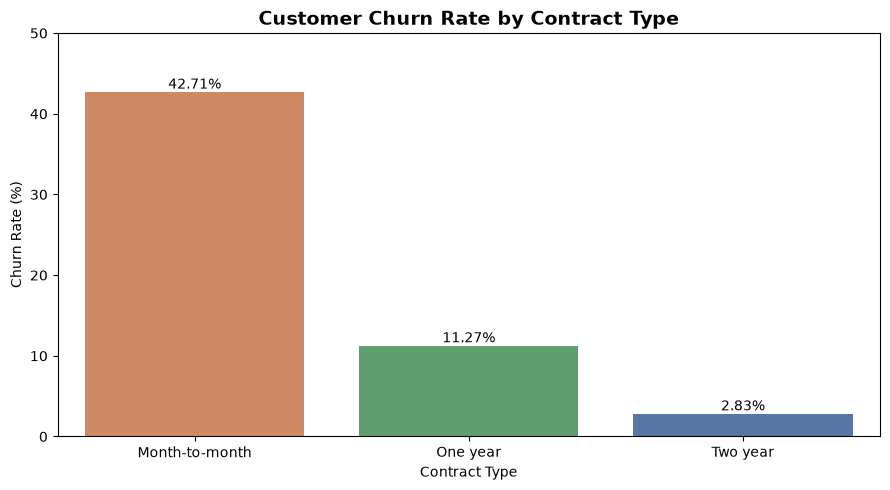

In [25]:
contract_order = ["Month-to-month", "One year", "Two year"]

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=contract_churn_summary.reset_index(),
    x="Contract",
    y="Churn_Rate_Percent",
    hue="Contract",
    order=contract_order,
    palette={
        "Month-to-month": "#DD8452",
        "One year": "#55A868",
        "Two year": "#4C72B0"
    },
    legend=False
)

plt.title("Customer Churn Rate by Contract Type", fontsize=14, fontweight="bold")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for bar in ax.patches:
    churn_rate = bar.get_height()
    ax.annotate(
        f"{churn_rate:.2f}%",
        (bar.get_x() + bar.get_width() / 2, churn_rate),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Business Insight

Contract type has a strong association with customer churn.

- Customers on month-to-month contracts have the highest churn rate at **42.71%**.
- Customers on one-year contracts have a substantially lower churn rate of **11.27%**.
- Customers on two-year contracts have the lowest churn rate at only **2.83%**.

This pattern suggests that customers with longer commitments are much more likely to remain
with the company, while month-to-month customers represent the highest-risk segment.

**Business implication:** The retention team should prioritize month-to-month customers for
proactive engagement. Suitable interventions may include personalized renewal offers,
discounts for annual contracts, bundled services, loyalty incentives, and improved early-stage
onboarding. The company should also investigate whether flexibility, pricing, service quality,
or limited engagement explains the high churn rate in this segment.

## 2.3 Churn Rate by Customer Tenure Group

This analysis groups customers according to the number of months they have been with the
company to identify the stages of the customer lifecycle with the highest churn risk.

In [26]:
# Create customer lifecycle groups based on tenure in months
tenure_bins = [-1, 12, 24, 48, 72]

tenure_labels = [
    "0-12 months",
    "13-24 months",
    "25-48 months",
    "49-72 months"
]

df["TenureGroup"] = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels
)

tenure_churn_summary = (
    df.groupby("TenureGroup", observed=False)["Churn"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda x: (x == "Yes").sum()
    )
)

tenure_churn_summary["Churn_Rate_Percent"] = (
    tenure_churn_summary["Churned_Customers"]
    / tenure_churn_summary["Total_Customers"]
    * 100
).round(2)

tenure_churn_summary

,Total_Customers,Churned_Customers,Churn_Rate_Percent
TenureGroup,,,
0-12 months,2186,1037,47.44
13-24 months,1024,294,28.71
25-48 months,1594,325,20.39
49-72 months,2239,213,9.51


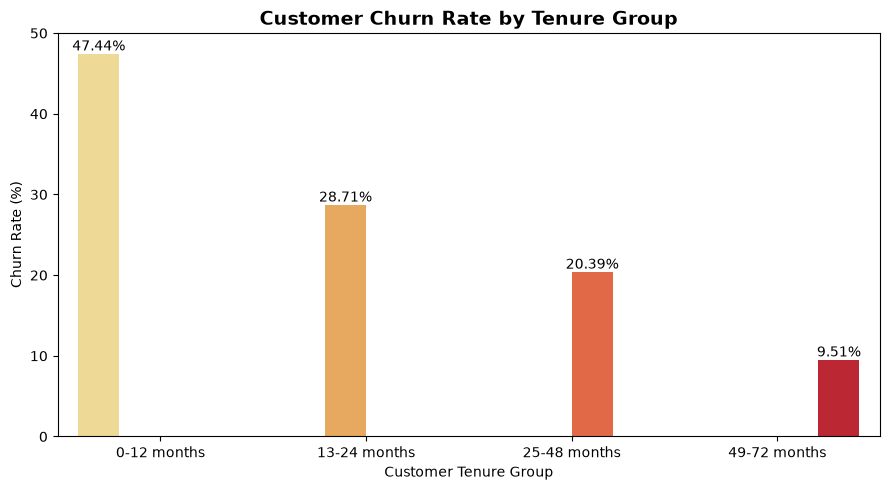

In [27]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=tenure_churn_summary.reset_index(),
    x="TenureGroup",
    y="Churn_Rate_Percent",
    hue="TenureGroup",
    palette="YlOrRd",
    legend=False
)

plt.title("Customer Churn Rate by Tenure Group", fontsize=14, fontweight="bold")
plt.xlabel("Customer Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for bar in ax.patches:
    churn_rate = bar.get_height()
    ax.annotate(
        f"{churn_rate:.2f}%",
        (bar.get_x() + bar.get_width() / 2, churn_rate),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Business Insight

Customer churn decreases substantially as tenure increases.

- Customers with **0–12 months** of tenure have the highest churn rate at **47.44%**.
- The churn rate declines to **28.71%** for customers with **13–24 months** of tenure.
- It further declines to **20.39%** for customers with **25–48 months** of tenure.
- Long-term customers with **49–72 months** of tenure have the lowest churn rate at
  **9.51%**.

This indicates that the first year is the most critical period for customer retention.
New customers may be more likely to leave because they have not yet experienced sufficient
service value, loyalty, satisfaction, or switching barriers.

**Business implication:** The company should implement a structured early-lifecycle retention
programme. Possible actions include onboarding calls, service-usage guidance, proactive
technical support, first-year loyalty rewards, targeted plan reviews, and personalized offers
before the customer’s first contract-renewal decision.

## 2.4 Churn Rate by Internet Service Type

This analysis examines whether customer churn differs according to the type of internet
service subscribed to by the customer.

In [28]:
internet_churn_summary = (
    df.groupby("InternetService")["Churn"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda x: (x == "Yes").sum()
    )
)

internet_churn_summary["Churn_Rate_Percent"] = (
    internet_churn_summary["Churned_Customers"]
    / internet_churn_summary["Total_Customers"]
    * 100
).round(2)

internet_order = ["DSL", "Fiber optic", "No"]

internet_churn_summary = internet_churn_summary.loc[internet_order]

internet_churn_summary

,Total_Customers,Churned_Customers,Churn_Rate_Percent
InternetService,,,
DSL,2421,459,18.96
Fiber optic,3096,1297,41.89
No,1526,113,7.40


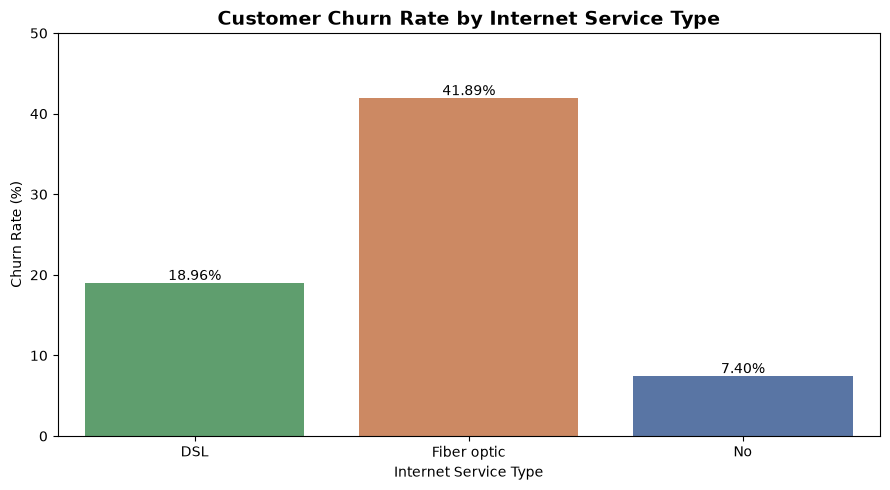

In [29]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=internet_churn_summary.reset_index(),
    x="InternetService",
    y="Churn_Rate_Percent",
    hue="InternetService",
    order=internet_order,
    palette={
        "DSL": "#55A868",
        "Fiber optic": "#DD8452",
        "No": "#4C72B0"
    },
    legend=False
)

plt.title("Customer Churn Rate by Internet Service Type", fontsize=14, fontweight="bold")
plt.xlabel("Internet Service Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for bar in ax.patches:
    churn_rate = bar.get_height()
    ax.annotate(
        f"{churn_rate:.2f}%",
        (bar.get_x() + bar.get_width() / 2, churn_rate),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Business Insight

Customer churn differs substantially by internet service type.

- Customers using **Fiber optic** internet have the highest churn rate at **41.89%**.
- Customers using **DSL** have a lower churn rate of **18.96%**.
- Customers with **no internet service** have the lowest churn rate at **7.40%**.

The churn rate among Fiber optic customers is more than twice the churn rate among DSL
customers and substantially higher than the overall churn rate of 26.54%.

**Business implication:** Fiber optic customers should be investigated as a priority risk
segment. The company should examine service reliability, speed expectations, customer support,
complaint patterns, plan pricing, and perceived value. Targeted retention actions could include
service-quality follow-ups, proactive technical support, plan optimization, or personalized
loyalty offers for high-risk Fiber optic subscribers.

This finding shows association, not causation. Fiber optic customers may also differ from
other customers in contract type, monthly charges, tenure, or payment method.

## 2.5 Monthly Charges by Churn Status

This analysis compares the monthly charge distribution of churned and retained customers
to determine whether pricing or perceived value may be associated with churn.

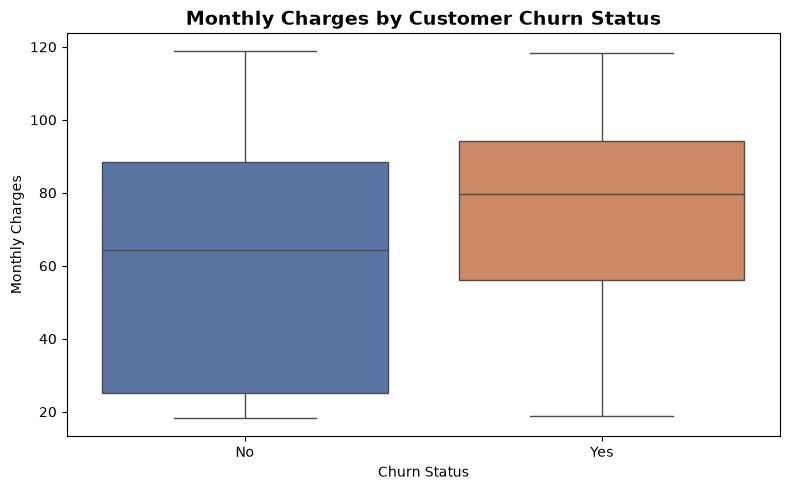

In [30]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    order=["No", "Yes"],
    palette={"No": "#4C72B0", "Yes": "#DD8452"},
    legend=False
)

plt.title("Monthly Charges by Customer Churn Status", fontsize=14, fontweight="bold")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

In [31]:
monthly_charges_summary = (
    df.groupby("Churn")["MonthlyCharges"]
    .agg(["count", "mean", "median", "min", "max", "std"])
    .round(2)
)

monthly_charges_summary

,count,mean,median,min,max,std
Churn,,,,,,
No,5174,61.27,64.43,18.25,118.75,31.09
Yes,1869,74.44,79.65,18.85,118.35,24.67


### Business Insight

Customers who churned had higher monthly charges than customers who remained with the
company.

| Churn Status | Mean Monthly Charges | Median Monthly Charges |
|---|---:|---:|
| No | 61.27 | 64.43 |
| Yes | 74.44 | 79.65 |

Churned customers paid, on average, approximately **13.17 more per month** than retained
customers. The median monthly charge is also higher among churned customers, indicating that
this pattern is not driven only by a small number of unusually expensive accounts.

**Business implication:** Higher monthly charges may indicate price sensitivity or a lower
perceived value among some customers. The retention team should review high-charge customers,
especially those with month-to-month contracts, short tenure, or Fiber optic service. Potential
actions include plan optimization, value-added bundles, targeted discounts, or proactive
service-quality engagement.

This result indicates association rather than causation. Higher charges may be related to
other factors such as service type, add-on services, or contract type.

## 2.6 Churn Rate by Payment Method

This analysis examines whether churn behaviour differs according to customers' payment methods.
It helps identify potential billing and payment-related retention opportunities.

In [32]:
payment_churn_summary = (
    df.groupby("PaymentMethod")["Churn"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda x: (x == "Yes").sum()
    )
)

payment_churn_summary["Churn_Rate_Percent"] = (
    payment_churn_summary["Churned_Customers"]
    / payment_churn_summary["Total_Customers"]
    * 100
).round(2)

payment_order = [
    "Electronic check",
    "Mailed check",
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]

payment_churn_summary = payment_churn_summary.loc[payment_order]

payment_churn_summary

,Total_Customers,Churned_Customers,Churn_Rate_Percent
PaymentMethod,,,
Electronic check,2365,1071,45.29
Mailed check,1612,308,19.11
Bank transfer (automatic),1544,258,16.71
Credit card (automatic),1522,232,15.24


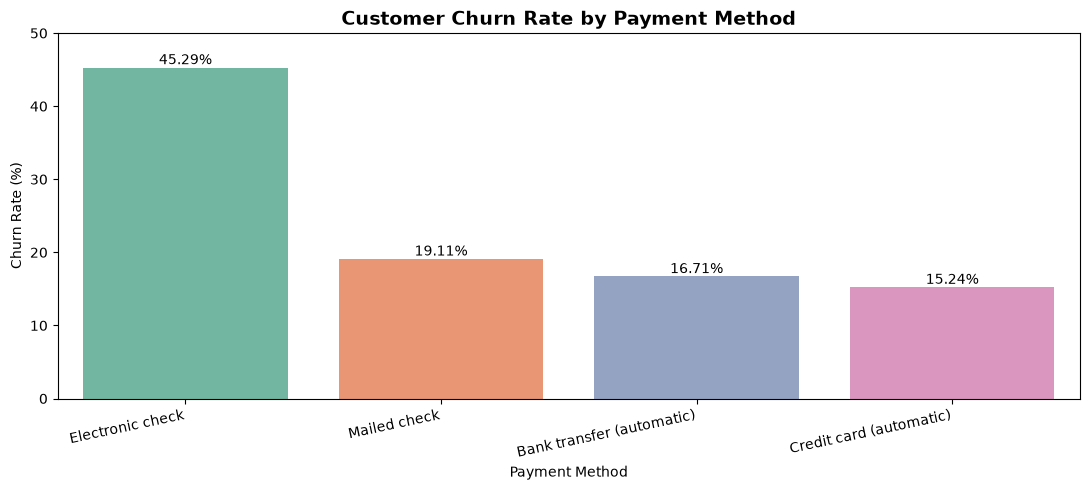

In [33]:
plt.figure(figsize=(11, 5))

ax = sns.barplot(
    data=payment_churn_summary.reset_index(),
    x="PaymentMethod",
    y="Churn_Rate_Percent",
    hue="PaymentMethod",
    order=payment_order,
    palette="Set2",
    legend=False
)

plt.title("Customer Churn Rate by Payment Method", fontsize=14, fontweight="bold")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=12, ha="right")
plt.ylim(0, 50)

for bar in ax.patches:
    churn_rate = bar.get_height()
    ax.annotate(
        f"{churn_rate:.2f}%",
        (bar.get_x() + bar.get_width() / 2, churn_rate),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Business Insight

Customer churn differs substantially by payment method.

| Payment Method | Churn Rate |
|---|---:|
| Electronic check | 45.29% |
| Mailed check | 19.11% |
| Bank transfer (automatic) | 16.71% |
| Credit card (automatic) | 15.24% |

Customers who use **electronic check** have the highest churn rate at **45.29%**.
This is approximately three times the churn rate of customers using automatic credit-card
payments.

**Business implication:** Customers using electronic checks should be prioritized for
proactive retention and payment-experience analysis. The company could encourage adoption of
automatic payment methods through simple enrollment, reminders, convenience incentives, or
targeted offers. It should also investigate whether electronic-check customers are more often
on month-to-month contracts, have shorter tenure, or experience greater price sensitivity.

This result shows an association, not proof that payment method itself causes churn.

## 2.7 Churn Rate by Technical Support Service

This analysis examines whether customers with technical support service have different
churn behaviour from customers without technical support.

In [34]:
tech_support_churn_summary = (
    df.groupby("TechSupport")["Churn"]
    .agg(
        Total_Customers="count",
        Churned_Customers=lambda x: (x == "Yes").sum()
    )
)

tech_support_churn_summary["Churn_Rate_Percent"] = (
    tech_support_churn_summary["Churned_Customers"]
    / tech_support_churn_summary["Total_Customers"]
    * 100
).round(2)

tech_support_order = ["No", "Yes", "No internet service"]

tech_support_churn_summary = tech_support_churn_summary.loc[tech_support_order]

tech_support_churn_summary

,Total_Customers,Churned_Customers,Churn_Rate_Percent
TechSupport,,,
No,3473,1446,41.64
Yes,2044,310,15.17
No internet service,1526,113,7.40


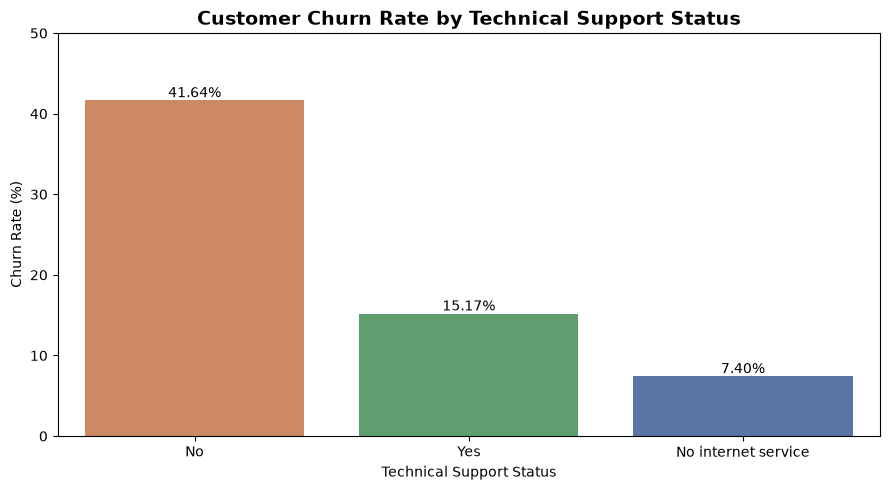

In [35]:
plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=tech_support_churn_summary.reset_index(),
    x="TechSupport",
    y="Churn_Rate_Percent",
    hue="TechSupport",
    order=tech_support_order,
    palette={
        "No": "#DD8452",
        "Yes": "#55A868",
        "No internet service": "#4C72B0"
    },
    legend=False
)

plt.title("Customer Churn Rate by Technical Support Status", fontsize=14, fontweight="bold")
plt.xlabel("Technical Support Status")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 50)

for bar in ax.patches:
    churn_rate = bar.get_height()
    ax.annotate(
        f"{churn_rate:.2f}%",
        (bar.get_x() + bar.get_width() / 2, churn_rate),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Business Insight

Technical support status has a strong association with customer churn.

| Technical Support Status | Churn Rate |
|---|---:|
| No technical support | 41.64% |
| Has technical support | 15.17% |
| No internet service | 7.40% |

Customers without technical support have a churn rate of **41.64%**, compared with
**15.17%** among customers who have technical support.

This suggests that access to support may improve customer satisfaction, help resolve technical
problems, and strengthen the customer relationship. However, this result represents an
association rather than causal proof; technical-support customers may differ in tenure,
contract type, internet service, or other characteristics.

**Business implication:** The retention team should prioritize high-risk customers without
technical support, particularly those with Fiber optic service, high monthly charges,
month-to-month contracts, or short tenure. The company could test targeted technical-support
trials, onboarding assistance, proactive service-health checks, and bundles that include
support services.

## Step 2 Summary: Exploratory Data Analysis

The EDA identified several customer segments with elevated churn risk:

- **Month-to-month contract customers** had the highest contract-based churn rate at 42.71%.
- **New customers with 0–12 months of tenure** had the highest lifecycle churn rate at 47.44%.
- **Fiber optic customers** had a churn rate of 41.89%.
- **Electronic-check customers** had a churn rate of 45.29%.
- Customers **without technical support** had a churn rate of 41.64%.
- Customers who churned had higher monthly charges on average (74.44) than retained customers
  (61.27).

These findings suggest that churn risk is associated with customer tenure, contract commitment,
internet-service type, payment behaviour, technical-support status, and monthly charges.

The retention team should prioritize early-stage, month-to-month, high-charge, Fiber optic,
electronic-check, and no-technical-support customer segments for proactive intervention.
These EDA findings will guide feature engineering and model interpretation in later stages.

# Step 3: Feature Engineering

Feature engineering creates additional variables from existing customer information to
represent meaningful business patterns that may improve churn prediction.

All engineered features in this project are calculated only from information available at
the time of prediction. The target variable (`Churn`) is not used to create any feature,
thereby avoiding target leakage.

## 3.1 Feature 1: TenureGroup

`TenureGroup` categorizes customer tenure into four lifecycle stages:

- `0-12 months`: New or early-stage customers
- `13-24 months`: Developing customer relationship
- `25-48 months`: Established customers
- `49-72 months`: Long-term customers

This feature is useful because EDA showed a strong decline in churn as tenure increases.
Grouping tenure can help the model capture lifecycle-related churn patterns in an interpretable
way, particularly the high-risk first-year customer segment.

In [36]:
tenure_group_summary = pd.DataFrame({
    "Customer Count": df["TenureGroup"].value_counts().sort_index(),
    "Percentage": (
        df["TenureGroup"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

tenure_group_summary

,Customer Count,Percentage
TenureGroup,,
0-12 months,2186,31.04
13-24 months,1024,14.54
25-48 months,1594,22.63
49-72 months,2239,31.79


## 3.2 Feature 2: ServiceCount

`ServiceCount` counts the number of active phone and internet-related services subscribed
to by each customer.

Only a value of `Yes` is counted as an active service. Values such as `No`,
`No phone service`, and `No internet service` are counted as zero.

This feature is useful because it represents customer engagement and service bundling.
Customers using more services may have stronger integration with the company and may face
higher switching costs, while customers with fewer services may be less engaged and more
likely to churn.

In [37]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = df[service_columns].eq("Yes").sum(axis=1)

print("ServiceCount created successfully.")
print(f"Minimum ServiceCount: {df['ServiceCount'].min()}")
print(f"Maximum ServiceCount: {df['ServiceCount'].max()}")

df[service_columns + ["ServiceCount"]].head()

ServiceCount created successfully.
Minimum ServiceCount: 0
Maximum ServiceCount: 8


,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,ServiceCount
0,No,No phone service,No,Yes,No,No,No,No,1
1,Yes,No,Yes,No,Yes,No,No,No,3
2,Yes,No,Yes,Yes,No,No,No,No,3
3,No,No phone service,Yes,No,Yes,Yes,No,No,3
4,Yes,No,No,No,No,No,No,No,1


## 3.3 Feature 3: SupportProtectionCount

`SupportProtectionCount` counts the number of active protection and support-related
services used by a customer:

- Online security
- Online backup
- Device protection
- Technical support

Only a value of `Yes` is counted as an active service.

This feature is useful because customers with more support and protection services may
be more engaged, experience fewer unresolved issues, and perceive greater value from
their relationship with the company. The EDA also showed that customers without
technical support had a substantially higher churn rate than customers with support.

In [38]:
support_protection_columns = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport"
]

df["SupportProtectionCount"] = (
    df[support_protection_columns]
    .eq("Yes")
    .sum(axis=1)
)

print("SupportProtectionCount created successfully.")
print(
    "Minimum SupportProtectionCount:",
    df["SupportProtectionCount"].min()
)
print(
    "Maximum SupportProtectionCount:",
    df["SupportProtectionCount"].max()
)

df[support_protection_columns + ["SupportProtectionCount"]].head()

SupportProtectionCount created successfully.
Minimum SupportProtectionCount: 0
Maximum SupportProtectionCount: 4


,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,SupportProtectionCount
0,No,Yes,No,No,1
1,Yes,No,Yes,No,2
2,Yes,Yes,No,No,2
3,Yes,No,Yes,Yes,3
4,No,No,No,No,0


In [39]:
print("Missing values in engineered features:")
print(
    df[["TenureGroup", "ServiceCount", "SupportProtectionCount"]]
    .isna()
    .sum()
)

print("\nServiceCount distribution:")
print(df["ServiceCount"].value_counts().sort_index())

print("\nSupportProtectionCount distribution:")
print(df["SupportProtectionCount"].value_counts().sort_index())

Missing values in engineered features:
TenureGroup               0
ServiceCount              0
SupportProtectionCount    0
dtype: int64

ServiceCount distribution:
ServiceCount
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

SupportProtectionCount distribution:
SupportProtectionCount
0    2793
1    1467
2    1372
3     941
4     470
Name: count, dtype: int64


### Feature Engineering Validation

The engineered features were successfully created and validated.

- `TenureGroup` contains four valid customer-lifecycle categories and has no missing values.
- `ServiceCount` ranges from 0 to 8, corresponding to the eight selected active phone
  and internet-related services.
- `SupportProtectionCount` ranges from 0 to 4, corresponding to the four selected
  support and protection services.
- No missing values were introduced by feature engineering.
- Only `Yes` values were counted as active services. `No`, `No phone service`, and
  `No internet service` were correctly treated as inactive services.

## Step 3 Summary: Feature Engineering

Three business-relevant features were created:

1. **TenureGroup:** Categorizes customers into lifecycle stages based on tenure.
2. **ServiceCount:** Counts active phone and internet-related services, representing
   customer engagement and service bundling.
3. **SupportProtectionCount:** Counts online security, online backup, device protection,
   and technical-support services, representing support and protection coverage.

All engineered features are calculated using only information available at prediction time.
Therefore, they can be recreated for new customers without target leakage.

# Step 4: Model Preparation

This section prepares the feature matrix and target variable for churn prediction.
The data will be split into training and test datasets using the required 70:30 ratio
and `random_state=42`.

To preserve the churn distribution in both datasets, a stratified split will be used.
All preprocessing transformations will later be fitted only on the training data through
a machine-learning pipeline to prevent data leakage.

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [41]:
# Define the target variable
y = df["Churn"]

# Define input features and exclude customerID because it is only an identifier
X = df.drop(columns=["customerID", "Churn"])

print(f"Number of input features before encoding: {X.shape[1]}")
print(f"Number of target values: {y.shape[0]}")

print("\nInput feature columns:")
print(X.columns.tolist())

print("\nTarget categories:")
print(y.value_counts())

Number of input features before encoding: 22
Number of target values: 7043

Input feature columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'TenureGroup', 'ServiceCount', 'SupportProtectionCount']

Target categories:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


### Feature Matrix and Target Definition

The target variable is `Churn`, with `Yes` representing a customer who churned and `No`
representing a retained customer.

`customerID` was excluded from the input features because it is a unique identifier and has
no meaningful business relationship with churn.

After excluding `customerID` and `Churn`, and adding the three engineered features
(`TenureGroup`, `ServiceCount`, and `SupportProtectionCount`), the final input dataset
contains **22 features before categorical encoding**.

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(f"Training feature shape: {X_train.shape}")
print(f"Testing feature shape: {X_test.shape}")

print("\nTraining target distribution (%):")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution (%):")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training feature shape: (4930, 22)
Testing feature shape: (2113, 22)

Training target distribution (%):
Churn
No     73.47
Yes    26.53
Name: proportion, dtype: float64

Testing target distribution (%):
Churn
No     73.45
Yes    26.55
Name: proportion, dtype: float64


In [43]:
split_summary = pd.DataFrame({
    "Dataset": ["Full Dataset", "Training Set", "Test Set"],
    "Rows": [len(df), len(X_train), len(X_test)],
    "Percentage of Full Dataset": [
        100.0,
        round(len(X_train) / len(df) * 100, 2),
        round(len(X_test) / len(df) * 100, 2)
    ],
    "Churn Rate (%)": [
        round((y == "Yes").mean() * 100, 2),
        round((y_train == "Yes").mean() * 100, 2),
        round((y_test == "Yes").mean() * 100, 2)
    ]
})

split_summary

,Dataset,Rows,Percentage of Full Dataset,Churn Rate (%)
0,Full Dataset,7043,100.0,26.54
1,Training Set,4930,70.0,26.53
2,Test Set,2113,30.0,26.55


### Train-Test Split Validation

The dataset was split into training and test sets using a 70:30 ratio with
`random_state=42`, as required.

| Dataset | Rows | Dataset Share | Churn Rate |
|---|---:|---:|---:|
| Full Dataset | 7,043 | 100.0% | 26.54% |
| Training Set | 4,930 | 70.0% | 26.53% |
| Test Set | 2,113 | 30.0% | 26.55% |

A stratified split was used to preserve the churn distribution in both subsets.
The nearly identical churn rates confirm that the training and test sets are
representative of the original dataset.

The test set will remain unseen during preprocessing, training, and model selection.
It will be used only for final model evaluation to provide an unbiased performance estimate.

In [44]:
numerical_features = X.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print(f"Number of numerical features: {len(numerical_features)}")
print(f"Number of categorical features: {len(categorical_features)}")
print(f"Total input features: {len(numerical_features) + len(categorical_features)}")

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Number of numerical features: 6
Number of categorical features: 16
Total input features: 22

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'SupportProtectionCount']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


In [45]:
all_identified_features = numerical_features + categorical_features

print(f"Unique features identified: {len(set(all_identified_features))}")
print(f"Actual features in X: {X.shape[1]}")

print("\nFeatures missing from type lists:")
print(sorted(set(X.columns) - set(all_identified_features)))

print("\nFeatures incorrectly included in type lists:")
print(sorted(set(all_identified_features) - set(X.columns)))

Unique features identified: 22
Actual features in X: 22

Features missing from type lists:
[]

Features incorrectly included in type lists:
[]


### Feature Type Identification

The 22 model input features were classified into:

- **6 numerical features:** `SeniorCitizen`, `tenure`, `MonthlyCharges`,
  `TotalCharges`, `ServiceCount`, and `SupportProtectionCount`.
- **16 categorical features:** demographic, service, contract, billing, and
  engineered lifecycle-group variables, including `TenureGroup`.

The feature lists were validated against the input dataset:

- Unique features identified: 22
- Actual input features: 22
- Features missing from type lists: None
- Incorrectly included features: None

## 4.1 Leakage-Safe Preprocessing Pipeline

Numerical and categorical variables require different preprocessing.

- Numerical variables will use median imputation if a value is missing.
- Categorical variables will use most-frequent-value imputation if a value is missing,
  followed by one-hot encoding.
- One-hot encoding converts category labels into numerical binary columns suitable for
  the Decision Tree model.
- `handle_unknown="ignore"` ensures that the pipeline can safely process a new customer
  record containing a previously unseen categorical value.

All preprocessing steps will be included inside a pipeline and fitted only on the training
dataset. This prevents data leakage and ensures that exactly the same preprocessing can be
reused for new customer predictions in the API.

In [46]:
# Numerical preprocessing: fill any future missing numeric values with the median
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical preprocessing: fill missing categories and one-hot encode categories
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Apply the appropriate preprocessing to each feature group
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [47]:
# Fit preprocessing only on training data, then transform both datasets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Original training shape: {X_train.shape}")
print(f"Processed training shape: {X_train_processed.shape}")

print(f"\nOriginal testing shape: {X_test.shape}")
print(f"Processed testing shape: {X_test_processed.shape}")

Original training shape: (4930, 22)
Processed training shape: (4930, 51)

Original testing shape: (2113, 22)
Processed testing shape: (2113, 51)


### Preprocessing Validation

The preprocessing pipeline was fitted only on the training dataset and then applied to
both the training and test datasets.

| Dataset | Original Shape | Processed Shape |
|---|---:|---:|
| Training Set | 4,930 × 22 | 4,930 × 51 |
| Test Set | 2,113 × 22 | 2,113 × 51 |

The feature count increased from 22 to 51 because one-hot encoding converted categorical
variables into binary numerical columns.

Both processed datasets contain the same 51 feature columns. This confirms that preprocessing
is applied consistently and that the test dataset was not used to fit transformation rules,
thereby preventing data leakage.

# Step 5: Model Development

A Decision Tree Classifier will be developed to predict customer churn.

At least two Decision Tree configurations will be trained and compared:

1. **Baseline Decision Tree:** Default parameters, used as a benchmark.
2. **Regularized Decision Tree:** Controlled tree depth and minimum sample requirements,
   designed to reduce overfitting and improve generalization.

All models will use the same leakage-safe preprocessing pipeline and the same 70:30
stratified train-test split.

In [48]:
# Model 1: Baseline Decision Tree using default settings
baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

# Train the baseline model on the training data
baseline_pipeline.fit(X_train, y_train)

# Generate predictions for training and test data
baseline_train_predictions = baseline_pipeline.predict(X_train)
baseline_test_predictions = baseline_pipeline.predict(X_test)

print("Baseline Decision Tree trained successfully.")

Baseline Decision Tree trained successfully.


In [49]:
baseline_results = pd.DataFrame({
    "Dataset": ["Training Set", "Test Set"],
    "Accuracy": [
        accuracy_score(y_train, baseline_train_predictions),
        accuracy_score(y_test, baseline_test_predictions)
    ],
    "Precision": [
        precision_score(y_train, baseline_train_predictions, pos_label="Yes"),
        precision_score(y_test, baseline_test_predictions, pos_label="Yes")
    ],
    "Recall": [
        recall_score(y_train, baseline_train_predictions, pos_label="Yes"),
        recall_score(y_test, baseline_test_predictions, pos_label="Yes")
    ],
    "F1 Score": [
        f1_score(y_train, baseline_train_predictions, pos_label="Yes"),
        f1_score(y_test, baseline_test_predictions, pos_label="Yes")
    ]
}).round(4)

baseline_results

,Dataset,Accuracy,Precision,Recall,F1 Score
0,Training Set,0.9980,1.0000,0.9924,0.9962
1,Test Set,0.7279,0.4876,0.4920,0.4898


### Model 1: Baseline Decision Tree Results

| Dataset | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Training Set | 99.80% | 100.00% | 99.24% | 99.62% |
| Test Set | 72.79% | 48.76% | 49.20% | 48.98% |

The baseline Decision Tree achieved almost perfect performance on the training dataset but
performed substantially worse on the unseen test dataset.

This large difference indicates **overfitting**. The unrestricted tree learned patterns that
were overly specific to the training records and did not generalize well to new customers.

For churn prediction, the test recall of 49.20% means that the model correctly identified
only about half of the customers who actually churned. Therefore, the baseline model is not
selected as the final model.

## 5.2 Model 2: Regularized Decision Tree

The baseline model showed severe overfitting. Therefore, a regularized Decision Tree is
trained with controlled depth and minimum-sample requirements.

The model also uses `class_weight="balanced"` to place greater importance on the minority
churn class (`Churn = Yes`), supporting the business objective of identifying customers
at risk of leaving.

In [50]:
# Model 2: Regularized Decision Tree
regularized_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=5,
                min_samples_split=20,
                min_samples_leaf=10,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

# Train the regularized model
regularized_pipeline.fit(X_train, y_train)

# Generate predictions
regularized_train_predictions = regularized_pipeline.predict(X_train)
regularized_test_predictions = regularized_pipeline.predict(X_test)

print("Regularized Decision Tree trained successfully.")

Regularized Decision Tree trained successfully.


In [51]:
regularized_results = pd.DataFrame({
    "Dataset": ["Training Set", "Test Set"],
    "Accuracy": [
        accuracy_score(y_train, regularized_train_predictions),
        accuracy_score(y_test, regularized_test_predictions)
    ],
    "Precision": [
        precision_score(y_train, regularized_train_predictions, pos_label="Yes"),
        precision_score(y_test, regularized_test_predictions, pos_label="Yes")
    ],
    "Recall": [
        recall_score(y_train, regularized_train_predictions, pos_label="Yes"),
        recall_score(y_test, regularized_test_predictions, pos_label="Yes")
    ],
    "F1 Score": [
        f1_score(y_train, regularized_train_predictions, pos_label="Yes"),
        f1_score(y_test, regularized_test_predictions, pos_label="Yes")
    ]
}).round(4)

regularized_results

,Dataset,Accuracy,Precision,Recall,F1 Score
0,Training Set,0.7331,0.4982,0.8479,0.6276
1,Test Set,0.7113,0.4741,0.7986,0.5950


In [52]:
model_comparison = pd.concat(
    [
        baseline_results.assign(Model="Baseline Decision Tree"),
        regularized_results.assign(Model="Regularized Decision Tree")
    ],
    ignore_index=True
)

model_comparison = model_comparison[
    ["Model", "Dataset", "Accuracy", "Precision", "Recall", "F1 Score"]
]

model_comparison

,Model,Dataset,Accuracy,Precision,Recall,F1 Score
0,Baseline Decision Tree,Training Set,0.9980,1.0000,0.9924,0.9962
1,Baseline Decision Tree,Test Set,0.7279,0.4876,0.4920,0.4898
2,Regularized Decision Tree,Training Set,0.7331,0.4982,0.8479,0.6276
3,Regularized Decision Tree,Test Set,0.7113,0.4741,0.7986,0.5950


In [53]:
def evaluate_model(model_name, fitted_pipeline, X_test, y_test):
    predictions = fitted_pipeline.predict(X_test)

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            pos_label="Yes",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            pos_label="Yes",
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            pos_label="Yes",
            zero_division=0
        )
    }

## Bonus: Decision Tree Hyperparameter Tuning

A GridSearchCV experiment is performed using stratified 5-fold cross-validation on the
training data only. The search evaluates Decision Tree complexity controls and class
weights.

Recall is used as the optimization metric because the business objective is to identify
customers likely to churn. Missing a true churner prevents the retention team from
taking proactive action.

In [54]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer

churn_recall_scorer = make_scorer(
    recall_score,
    pos_label="Yes",
    zero_division=0
)

decision_tree_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(random_state=42))
    ]
)

parameter_grid = {
    "model__max_depth": [3, 5, 7, None],
    "model__min_samples_leaf": [1, 5, 10],
    "model__class_weight": [None, "balanced"]
}

stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=decision_tree_tuning_pipeline,
    param_grid=parameter_grid,
    scoring=churn_recall_scorer,
    cv=stratified_cv,
    n_jobs=1,
    verbose=2,
    error_score="raise",
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("\nBest parameters:")
print(grid_search.best_params_)

print("\nBest mean 5-fold CV recall:")
print(round(grid_search.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END model__class_weight=None, model__max_depth=3, model__min_samples_leaf=1; total time=   0.2s
[CV] END model__class_weight=None, model__max_depth=3, model__min_samples_leaf=1; total time=   0.1s
[CV] END model__class_weight=None, model__max_depth=3, model__min_samples_leaf=1; total time=   0.2s
[CV] END model__class_weight=None, model__max_depth=3, model__min_samples_leaf=1; total time=   0.2s
[CV] END model__class_weight=None, model__max_depth=3, model__min_samples_leaf=1; total time=   0.2s
[CV] END model__class_weight=None, model__max_depth=3, model__min_samples_leaf=5; total time=   0.1s
[CV] END model__class_weight=None, model__max_depth=3, model__min_samples_leaf=5; total time=   0.1s
[CV] END model__class_weight=None, model__max_depth=3, model__min_samples_leaf=5; total time=   0.2s
[CV] END model__class_weight=None, model__max_depth=3, model__min_samples_leaf=5; total time=   0.1s
[CV] END model__class_weight=

## Bonus: Hyperparameter Tuning with GridSearchCV

A Decision Tree hyperparameter search was performed using `GridSearchCV` with
stratified 5-fold cross-validation on the training dataset only.

The objective was to maximize recall for `Churn = Yes`, because failing to identify an
actual churner prevents the retention team from taking proactive action.

The search evaluated:

- Maximum tree depth: 3, 5, 7, and unrestricted depth
- Minimum samples per leaf: 1, 5, and 10
- Class weights: default weighting and `balanced`

The best configuration was:

```text
class_weight = balanced
max_depth = 5
min_samples_leaf = 10
```

It achieved a mean 5-fold cross-validation churn recall of **0.7844**.

This result supports the use of a regularized, class-balanced Decision Tree: it improves
the identification of churn-risk customers while controlling excessive tree complexity.

In [55]:
grid_results = (
    pd.DataFrame(grid_search.cv_results_)
    .sort_values("rank_test_score")
    [
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "param_model__max_depth",
            "param_model__min_samples_leaf",
            "param_model__class_weight"
        ]
    ]
    .head(10)
    .rename(
        columns={
            "rank_test_score": "CV Rank",
            "mean_test_score": "Mean CV Recall",
            "std_test_score": "CV Recall Std. Dev.",
            "param_model__max_depth": "Max Depth",
            "param_model__min_samples_leaf": "Min Samples Leaf",
            "param_model__class_weight": "Class Weight"
        }
    )
)

grid_results.style.format(
    {
        "Mean CV Recall": "{:.4f}",
        "CV Recall Std. Dev.": "{:.4f}"
    }
)

,CV Rank,Mean CV Recall,CV Recall Std. Dev.,Max Depth,Min Samples Leaf,Class Weight
17,1,0.7844,0.0398,5,10,balanced
14,2,0.7814,0.0264,3,10,balanced
13,2,0.7814,0.0264,3,5,balanced
12,2,0.7814,0.0264,3,1,balanced
16,5,0.7752,0.0366,5,5,balanced
15,6,0.7744,0.0368,5,1,balanced
20,7,0.7576,0.0228,7,10,balanced
19,8,0.7470,0.0396,7,5,balanced
18,9,0.7447,0.0392,7,1,balanced
23,10,0.7385,0.0065,None,10,balanced


### Hyperparameter-Tuning Interpretation

The top GridSearchCV configuration achieved a mean 5-fold cross-validation recall of
**0.7844** for `Churn = Yes`.

All of the top ten configurations used `class_weight="balanced"`. This indicates that
giving additional importance to the minority churn class improves the model's ability to
identify customers who are likely to churn.

Moderately regularized trees performed best:

- The highest-ranked configuration used `max_depth=5` and `min_samples_leaf=10`.
- Shallow trees with `max_depth=3` also achieved strong recall around 0.7814.
- Deeper trees with `max_depth=7` and unrestricted depth had lower recall, suggesting
  that greater tree complexity does not improve generalization for this churn dataset.

The results support selecting a class-balanced, regularized Decision Tree for the
telecom retention use case.

In [56]:
tuned_pipeline = grid_search.best_estimator_

tuned_test_predictions = tuned_pipeline.predict(X_test)

tuned_test_metrics = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
        "Score": [
            accuracy_score(y_test, tuned_test_predictions),
            precision_score(
                y_test,
                tuned_test_predictions,
                pos_label="Yes",
                zero_division=0
            ),
            recall_score(
                y_test,
                tuned_test_predictions,
                pos_label="Yes",
                zero_division=0
            ),
            f1_score(
                y_test,
                tuned_test_predictions,
                pos_label="Yes",
                zero_division=0
            )
        ]
    }
)

tuned_test_metrics["Score"] = tuned_test_metrics["Score"].round(4)

tuned_test_metrics

,Metric,Score
0,Accuracy,0.7113
1,Precision,0.4741
2,Recall,0.7986
3,F1 Score,0.5950


In [57]:
tuning_validation_comparison = pd.DataFrame(
    [
        {
            "Model": "Manual Regularized Decision Tree",
            "Accuracy": accuracy_score(
                y_test,
                regularized_pipeline.predict(X_test)
            ),
            "Precision": precision_score(
                y_test,
                regularized_pipeline.predict(X_test),
                pos_label="Yes",
                zero_division=0
            ),
            "Recall": recall_score(
                y_test,
                regularized_pipeline.predict(X_test),
                pos_label="Yes",
                zero_division=0
            ),
            "F1 Score": f1_score(
                y_test,
                regularized_pipeline.predict(X_test),
                pos_label="Yes",
                zero_division=0
            )
        },
        {
            "Model": "GridSearchCV Tuned Decision Tree",
            "Accuracy": accuracy_score(
                y_test,
                tuned_pipeline.predict(X_test)
            ),
            "Precision": precision_score(
                y_test,
                tuned_pipeline.predict(X_test),
                pos_label="Yes",
                zero_division=0
            ),
            "Recall": recall_score(
                y_test,
                tuned_pipeline.predict(X_test),
                pos_label="Yes",
                zero_division=0
            ),
            "F1 Score": f1_score(
                y_test,
                tuned_pipeline.predict(X_test),
                pos_label="Yes",
                zero_division=0
            )
        }
    ]
)

tuning_validation_comparison[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
] = tuning_validation_comparison[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].round(4)

tuning_validation_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Manual Regularized Decision Tree,0.7113,0.4741,0.7986,0.595
1,GridSearchCV Tuned Decision Tree,0.7113,0.4741,0.7986,0.595


### Hyperparameter-Tuning Validation
The GridSearchCV-tuned Decision Tree and the manually regularized Decision Tree produced
the same test-set metrics:

| Metric | Score |
|---|---:|
| Accuracy | 0.7113 |
| Precision | 0.4741 |
| Recall | 0.7986 |
| F1 Score | 0.5950 |

The matching performance validates the original regularized Decision Tree design.

The final model remains the regularized, class-balanced Decision Tree with:

```text
max_depth = 5
min_samples_split = 20
min_samples_leaf = 10
class_weight = balanced
random_state = 42
```

This model is retained because it is interpretable, controls overfitting, and identifies
79.86% of actual churners in the unseen test set. The GridSearchCV result independently
confirmed that a depth of 5, a minimum leaf size of 10, and balanced class weighting are
appropriate for this churn-prediction problem.

## 5.3 Model Comparison and Final Model Selection

| Model | Dataset | Accuracy | Precision | Recall | F1 Score |
|---|---|---:|---:|---:|---:|
| Baseline Decision Tree | Training Set | 99.80% | 100.00% | 99.24% | 99.62% |
| Baseline Decision Tree | Test Set | 72.79% | 48.76% | 49.20% | 48.98% |
| Regularized Decision Tree | Training Set | 73.31% | 49.82% | 84.79% | 62.76% |
| Regularized Decision Tree | Test Set | 71.13% | 47.41% | 79.86% | 59.50% |

### Final Model Selection

The **Regularized Decision Tree** was selected as the final model.

Although the baseline model achieved slightly higher test accuracy (72.79% compared with
71.13%), it showed severe overfitting: its training F1 score was 99.62%, but its test F1
score fell to 48.98%.

The regularized model showed much better generalization because its training and test
performance were closer. More importantly, it achieved substantially higher test recall
for the churn class: **79.86%**, compared with **49.20%** for the baseline model.

For a telecom retention team, identifying actual customers who may churn is more important
than maximizing accuracy alone. The regularized model correctly identifies approximately
four out of every five churners, making it more useful for proactive retention campaigns.

In [58]:
final_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [
        accuracy_score(y_test, regularized_test_predictions),
        precision_score(
            y_test,
            regularized_test_predictions,
            pos_label="Yes"
        ),
        recall_score(
            y_test,
            regularized_test_predictions,
            pos_label="Yes"
        ),
        f1_score(
            y_test,
            regularized_test_predictions,
            pos_label="Yes"
        )
    ]
})

final_metrics["Score (%)"] = (
    final_metrics["Score"] * 100
).round(2)

final_metrics

,Metric,Score,Score (%)
0,Accuracy,0.711311,71.13
1,Precision,0.474074,47.41
2,Recall,0.798574,79.86
3,F1 Score,0.594954,59.50


In [59]:
print(
    classification_report(
        y_test,
        regularized_test_predictions,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.68      0.78      1552
       Churn       0.47      0.80      0.59       561

    accuracy                           0.71      2113
   macro avg       0.69      0.74      0.69      2113
weighted avg       0.79      0.71      0.73      2113



In [60]:
cm = confusion_matrix(
    y_test,
    regularized_test_predictions,
    labels=["No", "Yes"]
)

cm_df = pd.DataFrame(
    cm,
    index=["Actual: No Churn", "Actual: Churn"],
    columns=["Predicted: No Churn", "Predicted: Churn"]
)

cm_df

,Predicted: No Churn,Predicted: Churn
Actual: No Churn,1055,497
Actual: Churn,113,448


## 5.4 Final Model Evaluation: Confusion Matrix

The confusion matrix shows how the final Regularized Decision Tree classified
customers in the unseen test dataset.

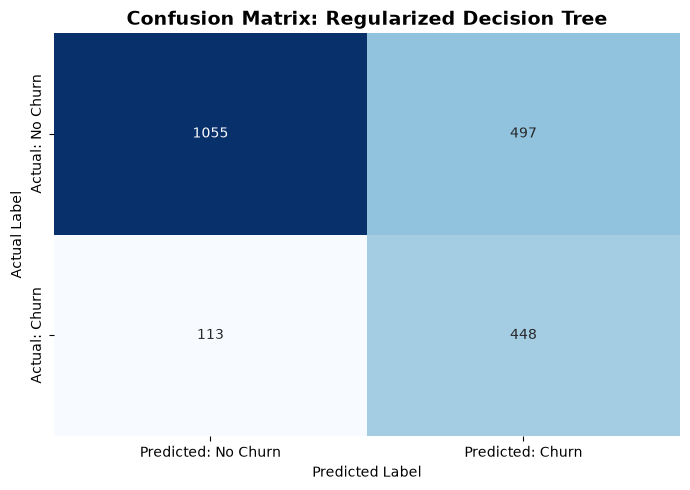

In [61]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted: No Churn", "Predicted: Churn"],
    yticklabels=["Actual: No Churn", "Actual: Churn"]
)

plt.title("Confusion Matrix: Regularized Decision Tree", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

### Confusion Matrix Interpretation

The final model was evaluated on 2,113 unseen test customers.

- **True Negatives (1,055):** Customers who did not churn and were correctly predicted
  as retained.
- **False Positives (497):** Customers who did not churn but were predicted to churn.
  These customers may receive unnecessary retention outreach or offers.
- **False Negatives (113):** Customers who churned but were predicted not to churn.
  These are missed retention opportunities.
- **True Positives (448):** Customers who churned and were correctly predicted to churn.
  These are the most valuable customers for proactive retention action.

The model identified 448 out of 561 actual churners, resulting in a recall of 79.86%.

### Business Interpretation of Final Model Performance

The final Regularized Decision Tree has an accuracy of 71.13%, precision of 47.41%,
recall of 79.86%, and F1 score of 59.50% on unseen test data.

The model correctly identified 448 of 561 customers who actually churned. This is useful
for a retention team because it enables the company to contact a large proportion of
at-risk customers before they leave.

The model also generated 497 false positives. These customers did not churn but were
flagged as at risk. This creates additional retention-campaign cost, but it may be
acceptable if outreach is low-cost or if the offer is targeted carefully.

The model missed 113 actual churners. Reducing these false negatives remains important
because each missed churner represents a lost opportunity to retain customer revenue.

Overall, the model is suitable as a prioritization tool rather than an automatic decision
system. Retention teams should combine its churn probability with campaign budget,
customer value, and offer eligibility before taking action.

## 5.5 Precision versus Recall for Churn Prediction

For a telecom company seeking to identify customers who may churn, **recall should be
prioritized**, while maintaining an acceptable level of precision.

- A **false negative** occurs when a customer is predicted not to churn but actually
  churns. The company misses the opportunity to intervene and may lose future customer revenue.
- A **false positive** occurs when a customer is predicted to churn but does not churn.
  The company may spend retention effort or provide an unnecessary offer.

In this business context, missing a genuine churner is generally more costly than contacting
some customers who would have remained. Therefore, the final model was selected partly because
it achieved a high churn recall of **79.86%**.

However, precision remains important because a very low precision would create excessive
campaign costs. In practice, the business can adjust the churn-probability threshold according
to retention-team capacity, customer lifetime value, and the cost of retention incentives.

# Step 6: Model Interpretation

This section explains the factors that drive churn predictions from the selected
Regularized Decision Tree model.

Model interpretation helps the retention team understand not only which customers
are at risk of

In [62]:
# Extract the fitted preprocessing component from the final model pipeline
fitted_preprocessor = regularized_pipeline.named_steps["preprocessor"]

# Extract all feature names after numerical processing and one-hot encoding
transformed_feature_names = fitted_preprocessor.get_feature_names_out()

print(f"Total transformed features: {len(transformed_feature_names)}")
print("\nFirst 15 transformed feature names:")
print(transformed_feature_names[:15])

Total transformed features: 51

First 15 transformed feature names:
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'num__ServiceCount' 'num__SupportProtectionCount'
 'cat__gender_Female' 'cat__gender_Male' 'cat__Partner_No'
 'cat__Partner_Yes' 'cat__Dependents_No' 'cat__Dependents_Yes'
 'cat__PhoneService_No' 'cat__PhoneService_Yes' 'cat__MultipleLines_No']


In [63]:
# Extract feature-importance values from the final Decision Tree
feature_importances = regularized_pipeline.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Importance": feature_importances
})

feature_importance_df["Importance (%)"] = (
    feature_importance_df["Importance"] * 100
).round(2)

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df.head(15)

,Feature,Importance,Importance (%)
0,cat__Contract_Month-to-month,0.609140,60.91
1,num__tenure,0.111881,11.19
2,cat__InternetService_Fiber optic,0.101444,10.14
3,num__MonthlyCharges,0.056854,5.69
4,num__TotalCharges,0.030857,3.09
5,cat__OnlineSecurity_No,0.018567,1.86
6,cat__TechSupport_No internet service,0.016497,1.65
7,cat__TechSupport_No,0.014776,1.48
8,cat__PaymentMethod_Electronic check,0.014327,1.43
9,cat__StreamingMovies_Yes,0.006656,0.67


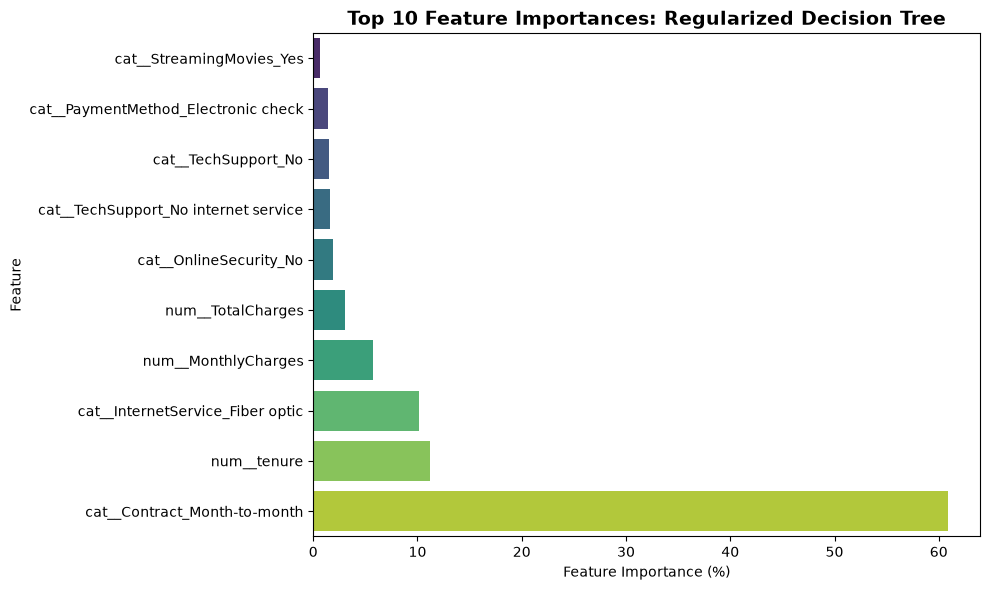

In [64]:
top_n = 10
top_features = feature_importance_df.head(top_n).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_features,
    x="Importance (%)",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Top 10 Feature Importances: Regularized Decision Tree",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Feature Importance (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 6.1 Feature Importance Findings

The Regularized Decision Tree identified the following top drivers of churn prediction:

| Rank | Feature | Importance |
|---:|---|---:|
| 1 | Month-to-month contract | 60.91% |
| 2 | Customer tenure | 11.19% |
| 3 | Fiber optic internet service | 10.14% |
| 4 | Monthly charges | 5.69% |
| 5 | Total charges | 3.09% |
| 6 | No online security | 1.86% |
| 7 | No internet service for technical support | 1.65% |
| 8 | No technical support | 1.48% |
| 9 | Electronic-check payment method | 1.43% |
| 10 | Streaming movies service | 0.67% |

The model relies most heavily on whether a customer has a **month-to-month contract**.
This result is consistent with EDA, where month-to-month customers had the highest churn
rate of 42.71%.

Customer tenure and Fiber optic service are the next strongest model drivers, also
supporting the EDA findings that early-tenure customers and Fiber optic customers had
elevated churn rates.

Monthly charges, total charges, online security, technical support, and electronic-check
payment behaviour provide additional signals that help the model identify potentially
high-risk customers.

Feature importance indicates the contribution of a variable to the model's decision rules.
It shows association within this dataset and should not be interpreted as causal proof.

### Business Actions Suggested by Model Interpretation

The feature-importance results suggest the following retention priorities:

- Prioritize **month-to-month customers**, especially those with short tenure, for
  personalized contract-conversion and loyalty offers.
- Strengthen onboarding and first-year retention efforts because customer tenure is a
  major churn signal.
- Investigate Fiber optic customers for service-quality, pricing, perceived-value, and
  support-related concerns.
- Review high monthly-charge customers for plan suitability, value-added services, or
  targeted retention discounts.
- Offer online security and technical-support trials or bundles to suitable high-risk
  customers who do not currently use these services.
- Review the payment journey for electronic-check users and encourage convenient automatic
  payment methods where appropriate.

## 6.2 Decision Tree Visualization

The following visualization shows the decision rules used by the final Regularized
Decision Tree. Each internal node represents a condition, and each leaf node represents
the predicted churn class based on the customers reaching that rule.

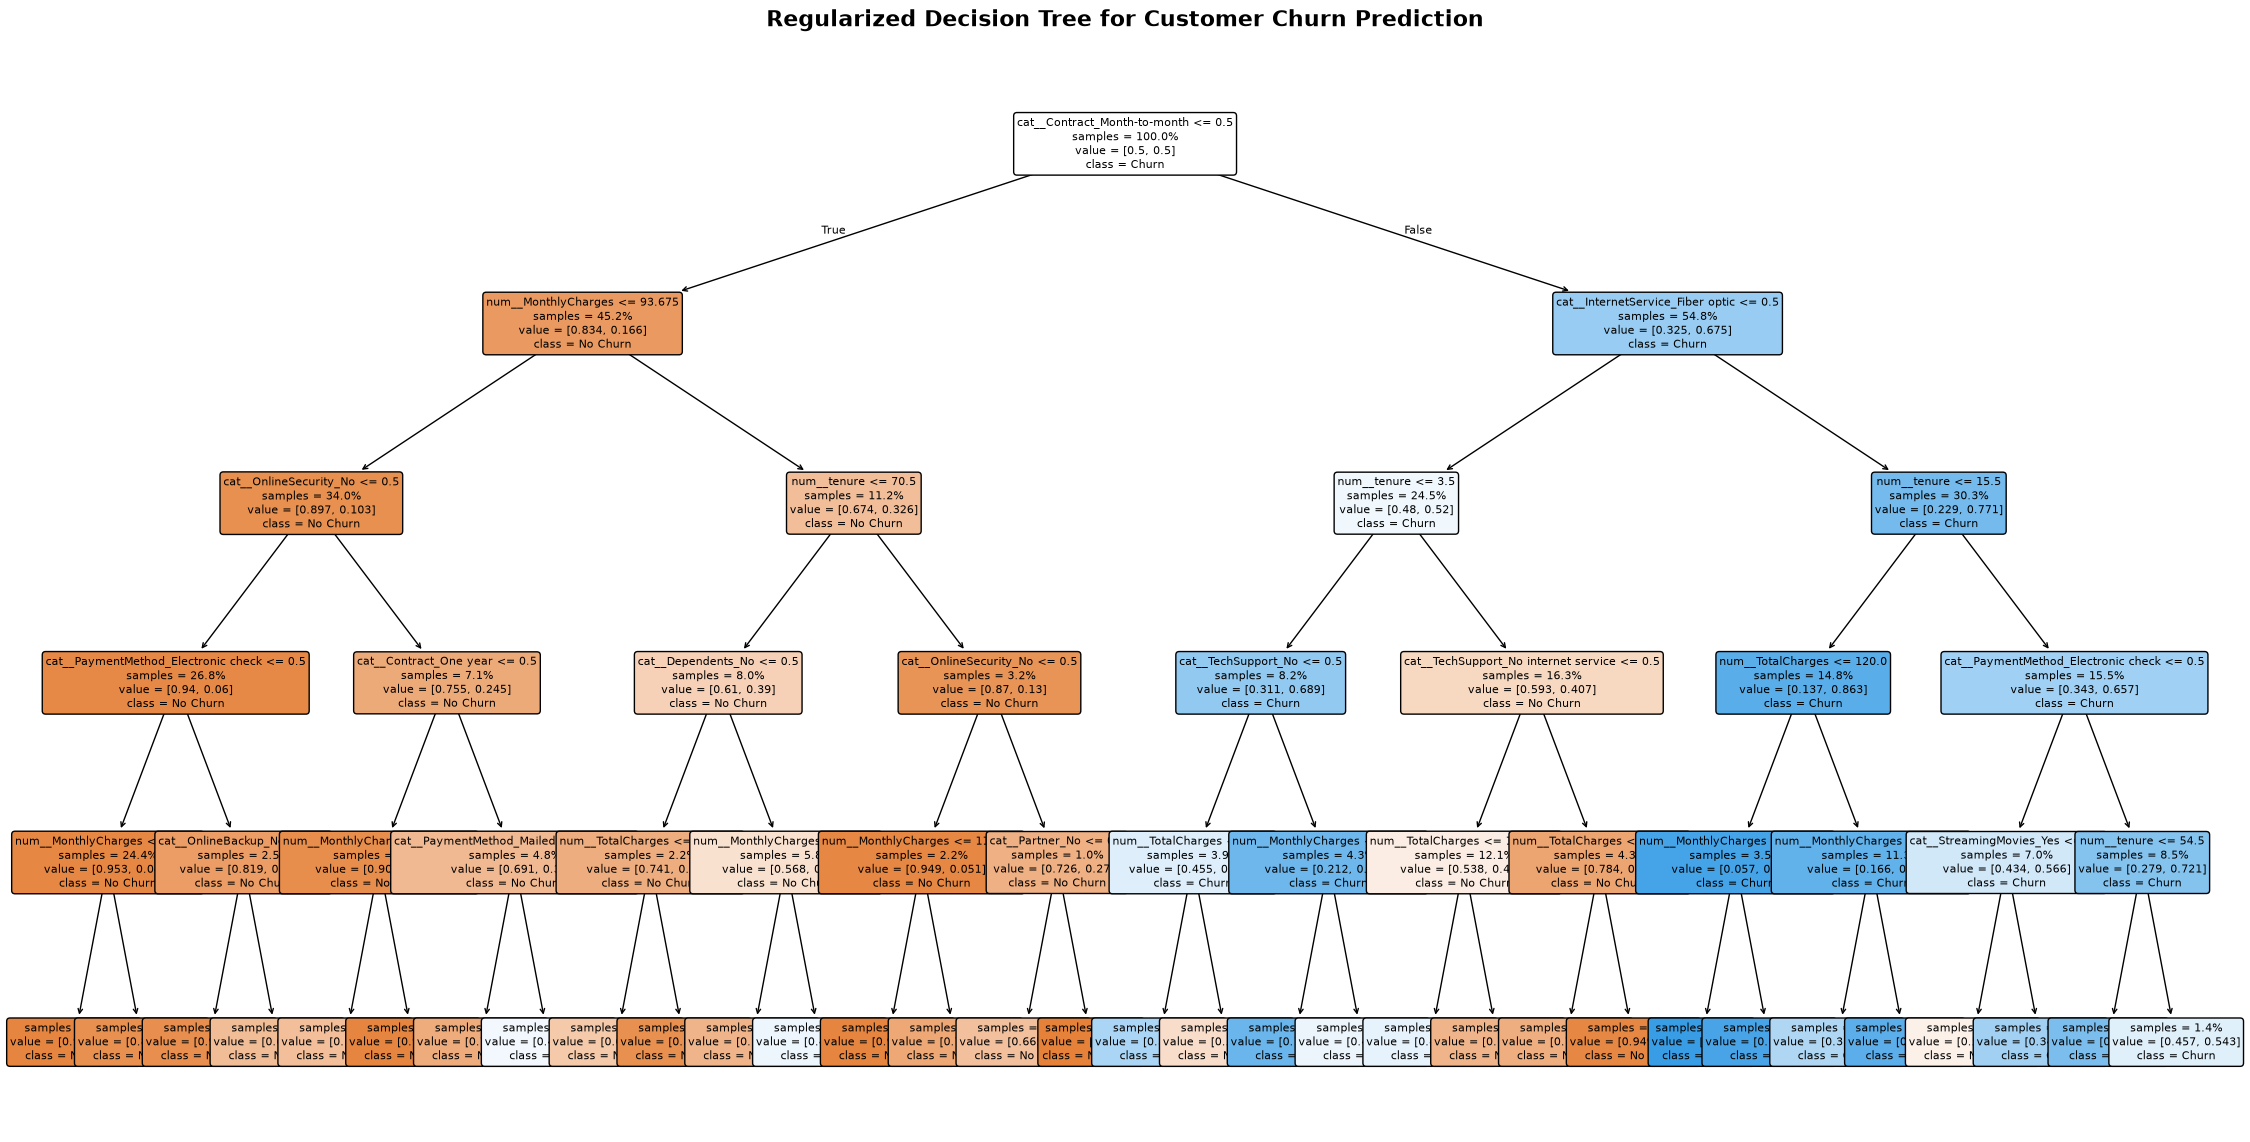

In [65]:
from sklearn.tree import plot_tree

final_tree_model = regularized_pipeline.named_steps["model"]

plt.figure(figsize=(28, 14))

plot_tree(
    final_tree_model,
    feature_names=transformed_feature_names,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    impurity=False,
    proportion=True,
    fontsize=8
)

plt.title(
    "Regularized Decision Tree for Customer Churn Prediction",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.show()

## 6.3 Decision Tree Rule Interpretation

The root node of the final Decision Tree is:

```text
Contract_Month-to-month <= 0.5
```

This means the model first determines whether a customer is on a month-to-month contract.

- A value greater than 0.5 indicates that the customer has a month-to-month contract.
- A value less than or equal to 0.5 indicates that the customer has a one-year or
  two-year contract.

This is consistent with the feature-importance analysis, where month-to-month contract status
was the most influential feature, and with EDA, where month-to-month customers had the highest
churn rate.

The next important decision rules use:

- **Monthly charges:** The tree uses a threshold near 93.68 to distinguish higher-charge
  customer segments.
- **Fiber optic service:** The tree separates Fiber optic customers from non-Fiber-optic
  customers because their churn patterns differ.
- **Online security:** The tree considers whether a customer lacks online security, which
  may indicate lower service engagement or perceived value.
- **Tenure:** Thresholds near 3.5 and 15.5 months identify very new and early-stage
  customers, while a threshold near 70.5 identifies very long-term customers.

Overall, the tree predicts higher churn risk primarily for customer combinations involving
month-to-month contracts, short tenure, Fiber optic service, higher monthly charges, and
limited support/security services.

## Step 6 Summary: Model Interpretation

The Regularized Decision Tree is interpretable and identified clear churn-risk drivers.

- Month-to-month contract status was the strongest model feature, accounting for 60.91%
  of total feature importance.
- Customer tenure, Fiber optic service, monthly charges, and total charges were the next
  most influential factors.
- Lack of online security, lack of technical support, and electronic-check payment behaviour
  provided additional churn-related signals.
- The top decision rule first separates month-to-month customers from longer-contract
  customers, then refines the prediction using charges, service type, security/support
  status, and tenure.

These findings are aligned with the EDA results and can help the retention team focus
interventions on high-risk customer segments.

In [66]:
from pathlib import Path
import joblib

PROJECT_ROOT = Path.cwd().parent
MODEL_DIR = PROJECT_ROOT / "model"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "churn_pipeline.joblib"

joblib.dump(regularized_pipeline, MODEL_PATH)

print(f"Final churn pipeline saved successfully at: {MODEL_PATH}")
print(f"Model file exists: {MODEL_PATH.exists()}")
print(f"Saved file size: {MODEL_PATH.stat().st_size / 1024:.2f} KB")

Final churn pipeline saved successfully at: c:\Users\aadilhussain\source\repos\customer_churn_project\model\churn_pipeline.joblib
Model file exists: True
Saved file size: 13.38 KB


In [67]:
loaded_pipeline = joblib.load(MODEL_PATH)

print("Saved pipeline loaded successfully.")
print(type(loaded_pipeline))

Saved pipeline loaded successfully.
<class 'sklearn.pipeline.Pipeline'>


In [68]:
# Select five unseen customers from the test set
sample_customers = X_test.head(5)

# Compare predictions from the in-memory and reloaded pipelines
original_predictions = regularized_pipeline.predict(sample_customers)
loaded_predictions = loaded_pipeline.predict(sample_customers)

verification_result = pd.DataFrame({
    "Original Pipeline Prediction": original_predictions,
    "Reloaded Pipeline Prediction": loaded_predictions,
    "Predictions Match": original_predictions == loaded_predictions
})

verification_result

,Original Pipeline Prediction,Reloaded Pipeline Prediction,Predictions Match
0,Yes,Yes,True
1,No,No,True
2,Yes,Yes,True
3,No,No,True
4,No,No,True


In [69]:
all_predictions_match = verification_result["Predictions Match"].all()

print(f"All reloaded-model predictions match: {all_predictions_match}")

All reloaded-model predictions match: True


## Step 7.1: Model Pipeline Saving and Validation

The final Regularized Decision Tree and its preprocessing steps were saved together as:

```text
model/churn_pipeline.joblib
```

The saved pipeline was reloaded successfully and verified against five unseen test customers.
The reloaded model produced the same predictions as the original in-memory pipeline.

Saving preprocessing and the trained model as one pipeline ensures that new customer data is
cleaned, encoded, and predicted consistently during API deployment.

## Step 7.2: API Input Validation

The FastAPI endpoint validates incoming customer data before making a prediction.

An invalid test request was submitted with:

- An unsupported gender value: `Unknown`
- An invalid `SeniorCitizen` value: `3`, while only `0` and `1` are valid
- Missing required customer fields

The API correctly returned an HTTP **422 Unprocessable Content** response and provided
field-level validation details.

This prevents invalid or incomplete customer information from reaching the model and
improves the reliability of the deployed prediction service.

## Step 7.3: API Prediction Test

The FastAPI application was tested through the interactive Swagger UI at:

`http://127.0.0.1:8000/docs`

A valid customer JSON request returned the following successful response:

```json
{
  "prediction": "Yes",
  "churn_probability": 0.8501
}
```

The API therefore correctly:

- Accepted JSON customer information
- Created the engineered features used during training
- Applied the saved preprocessing and Decision Tree pipeline
- Returned the predicted churn class
- Returned the probability of `Churn = Yes`

The customer was predicted to churn with an estimated probability of **85.01%**.